<a href="https://colab.research.google.com/github/AhmadFebriyan5/menjalankan-code_machine-Learning/blob/main/bab_2_supervised_learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Bab 2  Supervised Learning

**Menjalankn Machine Learning dengan Python**

Notebook ini membahas klasifikasi dan regresi menggunakan scikit-learn. Dataset yang digunakan adalah dataset bawaan sehingga notebook dapat langsung dijalankan di Google Colab.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris, load_breast_cancer, make_regression
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LinearRegression, Ridge, LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    mean_squared_error, r2_score, ConfusionMatrixDisplay
)

print("Library berhasil diimpor.")


Library berhasil diimpor.


## 1. Klasifikasi Dataset Iris

Dataset Iris berisi data bunga dengan empat fitur. Targetnya itu jenis bunga Iris. disini datanya dibagi menjadi data training dan testing supaya kemampuan generalisasi model bisa diuji.


In [2]:
iris = load_iris()
X = iris.data
y = iris.target

print("Nama fitur:", iris.feature_names)
print("Nama kelas:", iris.target_names)
print("Ukuran data:", X.shape)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

print("Data training:", X_train.shape)
print("Data testing:", X_test.shape)


Nama fitur: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Nama kelas: ['setosa' 'versicolor' 'virginica']
Ukuran data: (150, 4)
Data training: (112, 4)
Data testing: (38, 4)


## 2. K-Nearest Neighbors (KNN)

KNN menentukan kelas data baru berdasarkan kelas sejumlah tetangga terdekat. Parameter `n_neighbors` menentukan jumlah tetangga yang digunakan.


Akurasi KNN: 0.9736842105263158
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        12
  versicolor       0.93      1.00      0.96        13
   virginica       1.00      0.92      0.96        13

    accuracy                           0.97        38
   macro avg       0.98      0.97      0.97        38
weighted avg       0.98      0.97      0.97        38



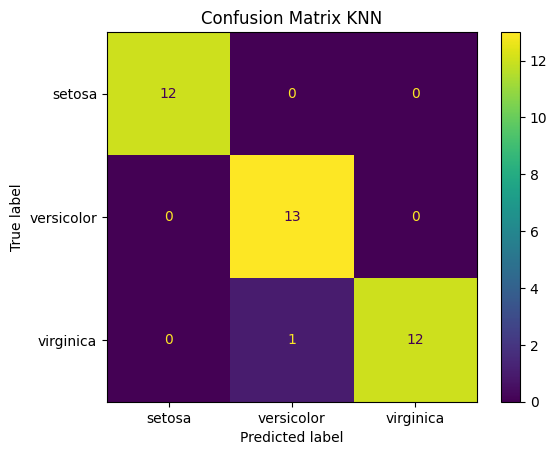

In [3]:
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train, y_train)

pred_knn = knn.predict(X_test)
akurasi_knn = accuracy_score(y_test, pred_knn)

print("Akurasi KNN:", akurasi_knn)
print(classification_report(y_test, pred_knn, target_names=iris.target_names))

ConfusionMatrixDisplay.from_predictions(
    y_test, pred_knn, display_labels=iris.target_names
)
plt.title("Confusion Matrix KNN")
plt.show()


## 3. Naive Bayes

Gaussian Naive Bayes menggunakan pendekatan probabilitas dan mengasumsikan bahwa fitur-fitur bersifat independen secara bersyarat terhadap kelas.


In [4]:
nb = GaussianNB()
nb.fit(X_train, y_train)

pred_nb = nb.predict(X_test)
akurasi_nb = accuracy_score(y_test, pred_nb)

print("Akurasi Naive Bayes:", akurasi_nb)
print(classification_report(y_test, pred_nb, target_names=iris.target_names))


Akurasi Naive Bayes: 0.9210526315789473
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        12
  versicolor       0.86      0.92      0.89        13
   virginica       0.92      0.85      0.88        13

    accuracy                           0.92        38
   macro avg       0.92      0.92      0.92        38
weighted avg       0.92      0.92      0.92        38



## 4. Decision Tree

Decision Tree membuat aturan keputusan berbentuk pohon. `max_depth` dapat digunakan untuk membatasi kompleksitas model dan mengurangi risiko overfitting.


Akurasi Decision Tree: 0.8947368421052632
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        12
  versicolor       0.80      0.92      0.86        13
   virginica       0.91      0.77      0.83        13

    accuracy                           0.89        38
   macro avg       0.90      0.90      0.90        38
weighted avg       0.90      0.89      0.89        38



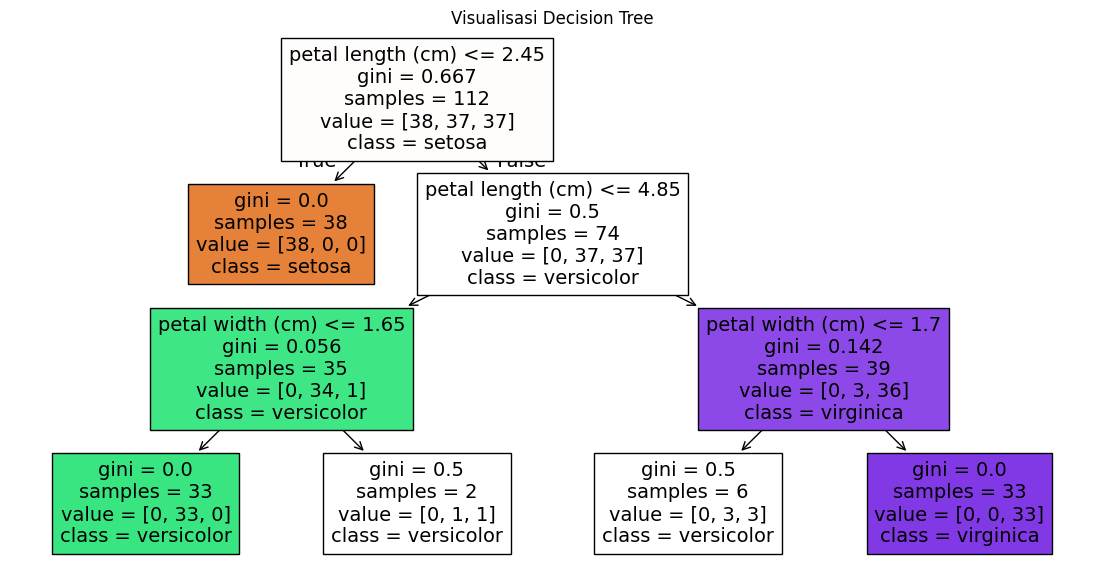

In [5]:
tree = DecisionTreeClassifier(max_depth=3, random_state=42)
tree.fit(X_train, y_train)

pred_tree = tree.predict(X_test)
akurasi_tree = accuracy_score(y_test, pred_tree)

print("Akurasi Decision Tree:", akurasi_tree)
print(classification_report(y_test, pred_tree, target_names=iris.target_names))

plt.figure(figsize=(14, 7))
plot_tree(
    tree,
    feature_names=iris.feature_names,
    class_names=iris.target_names,
    filled=True
)
plt.title("Visualisasi Decision Tree")
plt.show()


## 5. Perbandingan Model Klasifikasi

Bagian ini membandingkan akurasi KNN, Naive Bayes, dan Decision Tree pada data testing yang sama.


,Model,Akurasi
0,KNN,0.973684
1,Naive Bayes,0.921053
2,Decision Tree,0.894737


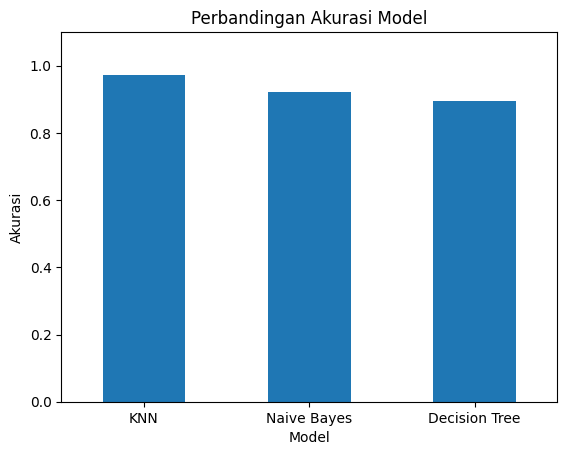

In [6]:
hasil_klasifikasi = pd.DataFrame({
    "Model": ["KNN", "Naive Bayes", "Decision Tree"],
    "Akurasi": [akurasi_knn, akurasi_nb, akurasi_tree]
})

display(hasil_klasifikasi)

hasil_klasifikasi.plot(
    x="Model", y="Akurasi", kind="bar", legend=False, ylim=(0, 1.1)
)
plt.ylabel("Akurasi")
plt.title("Perbandingan Akurasi Model")
plt.xticks(rotation=0)
plt.show()


## 6. Regresi Linear

Regresi digunakan buat memprediksi nilai numerik. Di contoh ini, data regresi dibuat secara sintetis.


Koefisien: [45.66329279]
Intercept: -0.597818320198165
RMSE: 15.848847235433716
R2 Score: 0.8587734717439844


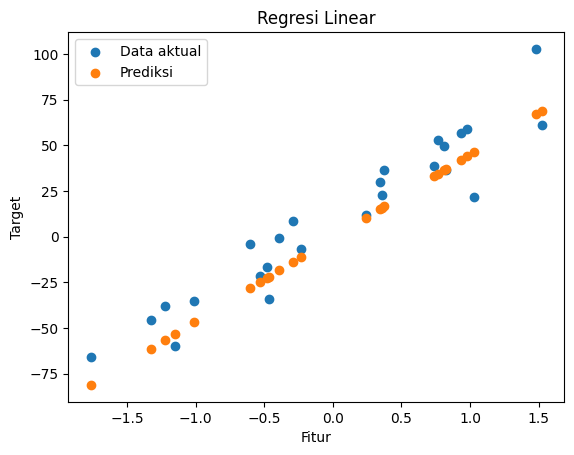

In [7]:
X_reg, y_reg = make_regression(
    n_samples=100, n_features=1, noise=15, random_state=42
)

Xr_train, Xr_test, yr_train, yr_test = train_test_split(
    X_reg, y_reg, test_size=0.25, random_state=42
)

linear = LinearRegression()
linear.fit(Xr_train, yr_train)
pred_linear = linear.predict(Xr_test)

print("Koefisien:", linear.coef_)
print("Intercept:", linear.intercept_)
print("RMSE:", mean_squared_error(yr_test, pred_linear) ** 0.5)
print("R2 Score:", r2_score(yr_test, pred_linear))

plt.scatter(Xr_test, yr_test, label="Data aktual")
plt.scatter(Xr_test, pred_linear, label="Prediksi")
plt.xlabel("Fitur")
plt.ylabel("Target")
plt.title("Regresi Linear")
plt.legend()
plt.show()


## 7. Regularisasi dengan Ridge

Ridge adalah regresi linear dengan penalti L2. Regularisasi dapat membantu mengurangi kompleksitas model, terutama ketika model memiliki risiko overfitting.


In [8]:
ridge = Ridge(alpha=1.0)
ridge.fit(Xr_train, yr_train)
pred_ridge = ridge.predict(Xr_test)

print("RMSE Ridge:", mean_squared_error(yr_test, pred_ridge) ** 0.5)
print("R2 Score Ridge:", r2_score(yr_test, pred_ridge))


RMSE Ridge: 15.90259040670067
R2 Score Ridge: 0.8578140543052654


## 8. Contoh Overfitting pada Decision Tree

Kita membandingkan pohon dengan kedalaman kecil dan pohon yang tidak dibatasi. Pohon yang terlalu kompleks dapat memperoleh skor training tinggi, tetapi belum tentu memiliki skor testing yang baik.


In [9]:
cancer = load_breast_cancer()
Xc_train, Xc_test, yc_train, yc_test = train_test_split(
    cancer.data, cancer.target, test_size=0.25, random_state=42, stratify=cancer.target
)

tree_simple = DecisionTreeClassifier(max_depth=3, random_state=42)
tree_complex = DecisionTreeClassifier(random_state=42)

tree_simple.fit(Xc_train, yc_train)
tree_complex.fit(Xc_train, yc_train)

hasil_overfitting = pd.DataFrame({
    "Model": ["Tree sederhana", "Tree kompleks"],
    "Akurasi training": [
        tree_simple.score(Xc_train, yc_train),
        tree_complex.score(Xc_train, yc_train)
    ],
    "Akurasi testing": [
        tree_simple.score(Xc_test, yc_test),
        tree_complex.score(Xc_test, yc_test)
    ]
})

display(hasil_overfitting)


,Model,Akurasi training,Akurasi testing
0,Tree sederhana,0.976526,0.944056
1,Tree kompleks,1.000000,0.923077


## Kesimpulan Bab 2

Supervised learning menggunakan data yang memiliki target atau label. KNN, Naive Bayes, dan Decision Tree bisa digunakan untuk klasifikasi, sedangkan Linear Regression dan Ridge dapat digunakan untuk regresi. Pembagian data training dan testing penting untuk mengukur kemampuan model pada data baru. Kompleksitas model juga perlu diperhatikan karena model yang terlalu kompleks dapat mengalami overfitting.
